In this notebook, we will implement a neural network from scratch using numpy and maths. This will greatly help in understanding the workings of a neural network in the most bare and crucial fashion. 

The Dataset that we are going to be using is the MNIST dataset of handwritten digits. The files are going to be "train.csv" and "test.csv". 

First, Importing the important libraries for the notebook. We will be using  
- Numpy - For maths implementation.
- pandas - for reading the dataset.
- matplotlib - for graphing images and other values. 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

After this, we will add our dataset for training. 

In [2]:
df = pd.read_csv("train.csv")

In [3]:
df.shape

(42000, 785)

In [4]:
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


We can also visualize the actual images instead of just pixel values using matplotlib.

In [5]:
df.sample()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
39573,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


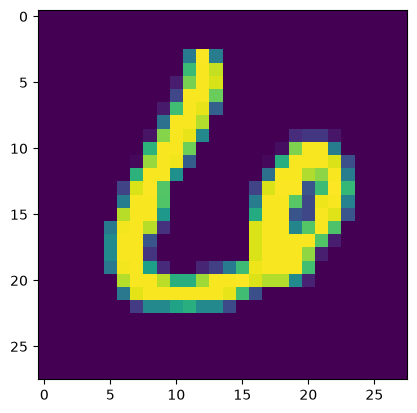

In [6]:
plt.imshow(df.iloc[1805, 1:].to_numpy().reshape(28, 28))

We want the dataset in form of a numpy array rather than a DataFrame.

In [7]:
data = np.array(df)
m,n = data.shape
# We are going to shuffle the data.
np.random.shuffle(data)

To avoid the risk of overfitting, we will be splitting the data into a dev data and a training data. We can train the model on training data and then perform cross validation on the dev data to test the hyperparameters to see the results, reducing the risk of overfitting on actual training data.

We will be transposing the arrays so that instead of rows as features, we would have columns are features. This would make things easier later on.

In [8]:
#Dev data
data_dev = data[0:1000].T #transposing the matrix.
Y_dev = data_dev[0] # actual label for cross validation.
X_dev = data_dev[1:n]  # These are the features of the label.

#Actual training data
data_train = data[1000:m].T #transposing the matrix
Y_train = data_train[0] # Actual labels
X_train = data_train[1:n]/ 255.0 # Features of labels

Here comes the real maths that will be used to create the neural network. 

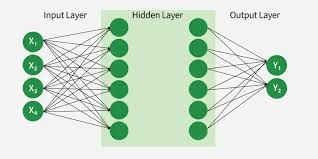  
Here is a simple neural network with 2 hidden layers. The first layer will be called a input layer. We will have the value of light in each pixel as input. As we have a 28px * 28px, we will be having the input layer of 784 neurons.  

The layer 1 and layer 2 (essentially hidden layers) are going to be of 10 neurons each.  

In the end would be the last layer for predicted output. This will also be from one neuron.

We will be using Linear Regression function for each layer.
The linear regression is given by: $ f(x) = w^{[p]}x + b^{[q]} $ where *p* and *q* are going to be notation of layer and ***w*** is going to be the *"weight"* and ***b*** is going to be *"bias"* for each neuron in layer 1 and 2.  

The weights and bias for each neuron is going to be set as random at first. Our goal is to tweak the weights and biases of each neuron multiple times so that we get the desired output(prediction).

So, Step 0 is going to be to define the parameters that will get tuned. 

In [9]:
def innit_params():
    W1 = (np.random.rand(10,784) - 0.5) *0.01
    b1 = (np.random.rand(10,1) - 0.5) *0.01

    W2 = np.random.rand(10,10) - 0.5
    b2 = np.random.rand(10,1) - 0.5

    return W1, b1, W2, b2

Above, we have also regularised the parameters so that the loss can be minimised and we can get better accuracy in training.

The training will consist of three parts:

1. **Forward Propogation** - Here, we just run the image(essentially the values of each pixel) in the neural network and find the output of the network.

The input layer will be called **X** containing all the pixel values. It will be of the dimensions: $\color{blue}{[784 \times m ]} $

The linear regression function can be added as: 

$$ 
Z^{[1]} = W^{[1]}X + b^{[1]}
$$  

If we just use the Linear regression function for our layer, The 1st layer we would get would just be a linear combination of input layer, and the 2nd layer also becomes the linear combination of first layer, which in-turn was already a linear combination of first layer.  
Due to this reason, we will apply an activation function; to make the layer more complex.

There are many activation functions like *tanh*, *sigmoid*, etc. We will use the $ ReLU $ function. The $ ReLU $ function looks like this: 
$$ 
f(x) = 
\begin{cases}
    0 & \text{if } x < 0 \\
    x & \text{if } x \geq 0
\end{cases}
$$

The graph looks like this: 

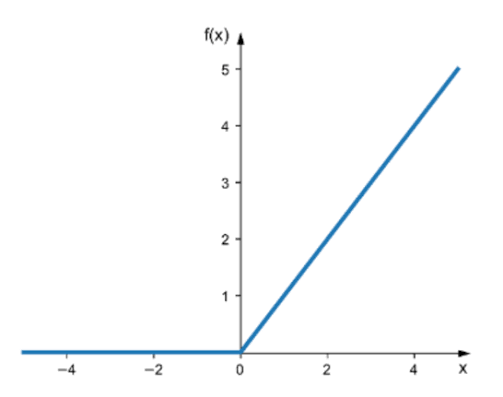

So, we will use $ A^{[1]} = ReLU(Z^{[1]}) $  

--------
For the second layer, we will be doing the same as the first one, i.e. using linear regression function. 

$$
Z^{[2]} = W^{[2]}A^{[1]} + b^{[2]}
$$  

Now that this is the last hidden layer, and we will have the prediction neuron after this, we would need to make sure that the the values that this layer spits out should be the probability of the label, making the highest probability as the prediction.  

We can use that by using another activation function called $ Softmax activation function $ which converts the values of all the neurons into probablistic values (between 0 and 1). 

The $ Softmax activation function $ is given by: 
$$
S(z)_i = \frac{e^{z_i}}{\sum{j=1}^{K} e^{z_j}}
$$

The graph looks like this:  


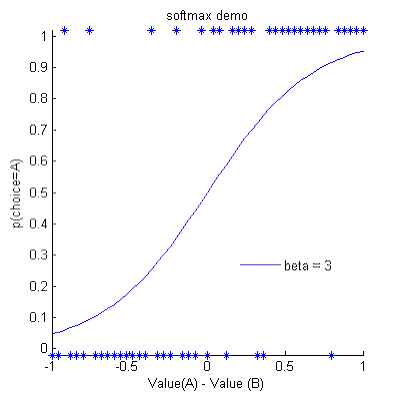



The working of function is given by:  


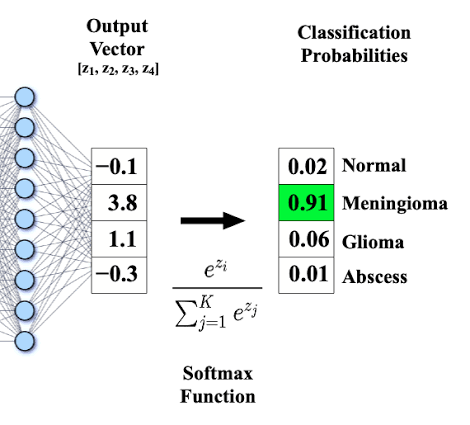

So, 
$$
A^{[2]} = Softmax(Z^{[2]})
$$

In [10]:
def ReLU(Z):
    return np.maximum(0,Z)

def SoftMax(Z):
    exp_Z = np.exp(Z - np.max(Z, axis=0, keepdims=True))
    return exp_Z / np.sum(exp_Z, axis=0, keepdims=True)

def forward_prop(W1, b1, W2, b2, X):
    Z1 = W1.dot(X) + b1
    A1 = ReLU(Z1)

    Z2 = W2.dot(A1) + b2
    A2 = SoftMax(Z2)

    return Z1, A1, Z2, A2

2. **Backward Propogation** - Here we will take the prediction of the layers and compare it to the orignal label, and understanding the deviation between them. After this, we would adjust those errors connected to each weights and biases.  

To do this we would need the output shown as Y, hot encoded, i.e. in the form of:  
$$
[4] = \begin{bmatrix}
        0 \\
        0 \\
        0 \\
        0 \\
        1 \\
        0 \\
        0 \\
        0 \\
        0 \\
        0 \\
        0 \\
\end{bmatrix}
$$

After this, we would go back from output layer to the layer 2 and we would adjust the weights and biases here. It would be done by:  
$$
dZ^{[2]} = A^{[2]} - Y
$$
$$ 
dW^{[2]} = \frac{1}{m} dZ^{[2]} A^{[1]T}
$$

$$
db^{[2]} = \frac{1}{m} \sum dZ^{[2]}
$$

For going back to 1st layer from second layer for adjustment of weights and biases, It would be done by: 
$$
dZ^{[1]} = W^{[2]T}dZ^{[2]} \times g'(Z^{[1]})
$$
where $ g'(Z^{[1]}) $ is the back propogation for the activation function that we used. The weights and biases are adjusted through:  
$$
dW^{[1]} = \frac{1}{m} dZ^{[1]} X^{T}
$$
$$
db^{[1]} = \frac{1}{m} \sum dZ^{[1]}
$$

In [11]:
def one_hot(Y):
    one_hot_Y = np.zeros((Y.size, Y.max() +1))
    one_hot_Y[np.arange(Y.size), Y] = 1
    one_hot_Y = one_hot_Y.T
    return one_hot_Y

def derivative_ReLU(Z):
    return Z > 0

def backward_prop(Z1, A1, Z2, A2, W2, X, Y):
    one_hot_Y = one_hot(Y)
    m = Y.size

    dZ2 = A2 - one_hot_Y
    dW2 = (dZ2.dot(A1.T)) / m
    db2 = np.sum(dZ2, axis=1, keepdims=True) / m
    dZ1 = W2.T.dot(dZ2) * derivative_ReLU(Z1)

    dW1 = (dZ1.dot(X.T)) / m
    db1 = np.sum(dZ1, axis=1, keepdims=True) / m

    return dW1, db1, dW2, db2

3. **Updating the values**  - In the last step, we would need to update the weights and biases with the updated weights and biases that we got during our back propogation for our gradient descent. Here, we will also introduce the hyperparameter of our neural network, i.e. "$\alpha$".  
'$\alpha$' is the *learning rate* of the neural network and is not adjusted by the model, but by us. The learning rate is the value which gives the model to take that big steps while finding the minima.  

The equations will be:
$$
W^{[1]} = W^{[1]} - \alpha.dW^{[1]}
$$
$$
b^{[1]} = b^{[1]} - \alpha.db^{[1]}
$$
$$
W^{[2]} = W^{[2]} - \alpha.dW^{[2]}
$$
$$
b^{[2]} = b^{[2]} - \alpha.db^{[2]}
$$

In [12]:
def update_parameters(W1, b1, W2, b2, dW1, db1, dW2, db2, lr):
    W1 = W1 - lr * dW1
    b1 = b1 - lr * db1
    W2 = W2 - lr * dW2
    b2 = b2 - lr * db2

    return W1, b1, W2, b2

These are all the functions that we would need to actually train the neural network and find the correct weights and biases. Now we just need to define the gradient function which calls the above functions step by step and then starts training the neural network on the given data, by the number of iterations provided.

In [13]:
def get_predictions(A):
    return np.argmax(A, 0)

def get_accuracy(predictions, Y):
    print(predictions, Y)
    return np.sum(predictions == Y) / Y.size

def gradient_descent(X, Y, iterations, lr):
    W1, b1, W2, b2 = innit_params()

    for i in range(iterations):
        Z1, A1, Z2, A2 = forward_prop(W1, b1, W2, b2, X)

        dW1, db1, dW2, db2 = backward_prop(Z1, A1, Z2, A2, W2, X, Y)

        W1, b1, W2, b2 = update_parameters(W1, b1, W2, b2, dW1, db1, dW2, db2, lr)

        if i % 50 == 0:
            print("Iterations: ", i)
            print("Accuracy: ", get_accuracy(get_predictions(A2), Y)*100 , "%")
    return W1, b1, W2, b2

Let's train the neural network now:

In [14]:
W1, b1, W2, b2 = gradient_descent(X_train, Y_train, 500, 0.1)

Iterations:  0
[3 3 3 ... 3 3 3] [3 7 8 ... 8 0 1]
Accuracy:  10.346341463414634 %
Iterations:  50
[3 2 9 ... 4 0 6] [3 7 8 ... 8 0 1]
Accuracy:  78.14878048780488 %
Iterations:  100
[3 2 9 ... 4 0 2] [3 7 8 ... 8 0 1]
Accuracy:  85.30975609756098 %
Iterations:  150
[3 2 8 ... 2 0 3] [3 7 8 ... 8 0 1]
Accuracy:  87.31951219512194 %
Iterations:  200
[3 2 8 ... 2 0 3] [3 7 8 ... 8 0 1]
Accuracy:  88.4609756097561 %
Iterations:  250
[3 2 8 ... 2 0 3] [3 7 8 ... 8 0 1]
Accuracy:  89.11707317073171 %
Iterations:  300
[3 2 8 ... 2 0 3] [3 7 8 ... 8 0 1]
Accuracy:  89.54146341463415 %
Iterations:  350
[3 2 8 ... 2 0 3] [3 7 8 ... 8 0 1]
Accuracy:  89.92926829268293 %
Iterations:  400
[3 2 8 ... 2 0 3] [3 7 8 ... 8 0 1]
Accuracy:  90.28048780487805 %
Iterations:  450
[3 2 8 ... 2 0 3] [3 7 8 ... 8 0 1]
Accuracy:  90.51463414634146 %


Now we will make the function to have a working prediction interface along with the image, so that we can also see the image and compare it to the prediction.

In [15]:
def make_predictions(X, W1, b1, W2, b2):
    _, _, _, A2 = forward_prop(W1, b1, W2, b2, X)
    predictions = get_predictions(A2)
    return predictions

def test_prediction(index, W1, b1, W2, b2):
    current_image = X_train[:, index, None]
    prediction = make_predictions(X_train[:, index, None], W1, b1, W2, b2)
    label = Y_train[index]
    print("Prediction: ", prediction)
    print("Label: ", label)

    current_image = current_image.reshape((28,28)) * 255
    plt.gray()
    plt.imshow(current_image, interpolation = 'nearest' )
    plt.show()

Let's use the functions:

Prediction:  [2]
Label:  2


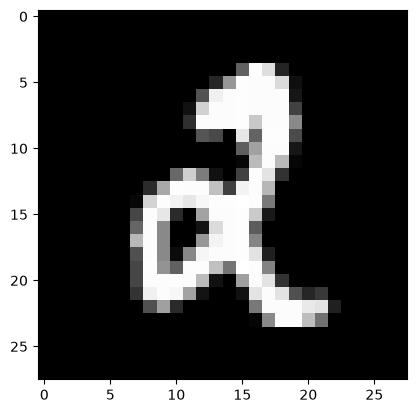

In [16]:
test_prediction(1805, W1, b1, W2, b2)

Now that the training is done and we have a very good accuracy, we shall test it on the *"dev"* data to see how well would it perform on the unseen data and to also make sure that the model hasn't overfitted.

In [17]:
dev_predictions = make_predictions(X_dev, W1, b1, W2, b2)
print("Accuracy : ", get_accuracy(dev_predictions, Y_dev)*100 , "%")

[1 1 7 9 6 4 2 7 3 4 4 5 3 8 8 3 5 4 8 9 1 8 4 2 2 6 1 7 2 8 4 9 2 6 4 9 5
 9 8 7 4 9 6 1 2 2 0 3 1 7 5 2 1 4 3 6 9 6 4 6 1 6 2 0 9 3 6 2 0 8 4 0 1 8
 5 1 4 3 6 3 9 6 6 4 7 6 6 6 4 1 3 1 0 1 1 3 6 5 5 3 8 4 0 1 0 0 1 8 6 7 6
 4 6 9 5 8 9 0 2 8 7 1 8 9 7 7 2 8 2 3 4 9 3 8 0 2 1 9 6 1 2 4 6 5 9 2 8 7
 4 9 0 5 0 5 1 1 2 7 2 5 7 7 3 6 1 3 2 6 8 6 8 9 3 1 9 6 9 1 0 1 2 4 6 1 1
 8 8 1 3 1 8 8 0 1 3 2 2 6 5 3 8 0 8 1 9 4 1 3 8 7 9 8 9 9 6 8 1 9 0 7 2 3
 2 0 9 5 7 9 4 7 4 2 0 9 8 9 4 7 9 8 8 7 5 7 3 9 7 2 5 1 1 5 9 7 7 8 2 4 9
 7 9 4 8 7 2 6 8 1 0 4 6 7 5 5 6 7 0 4 0 2 6 3 9 8 7 9 6 6 4 9 2 1 8 6 1 4
 3 0 0 1 8 5 5 8 8 6 6 8 7 8 0 9 7 1 1 5 1 6 7 0 4 0 1 1 4 1 9 0 6 2 4 1 8
 8 8 6 2 7 0 1 7 3 1 0 3 1 5 3 7 8 1 0 0 0 5 5 6 8 8 0 4 4 1 8 4 6 4 7 4 8
 9 8 7 1 0 3 5 0 6 8 8 5 8 9 6 3 7 1 3 6 1 7 9 7 5 0 1 4 2 3 5 5 9 3 3 8 9
 1 4 4 2 4 4 4 0 5 5 9 6 7 6 8 7 3 4 4 0 0 1 3 2 5 1 8 2 2 2 4 8 2 9 9 3 1
 4 3 3 1 5 1 7 5 9 3 5 7 1 4 3 4 5 0 1 6 0 3 0 0 7 6 0 3 9 3 0 4 6 6 2 8 3
 3 6 1 3 1 1 8 3 7 6 0 3 

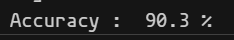  

The accuracy is stunning 90%, which is really good for a MNIST dataset. We can also tweak the learning rate and the number of iterations to get better accuracy as well. 